# A decade of European flood recurrence, in one query

A worked example with the [`euroflood`](https://github.com/cisgroup/euroflood) package,
reproducing the paper's headline application (main text Section 7.1, Fig. 5). It answers a
continental question, *how often has each place in Europe been detected as flooded over 2015 to
2024?*, from a **single discovery query**. Answering it from the raw archive would mean
downloading, aligning, and stacking thousands of event rasters; with the index it is a windowed
read, no rasters downloaded.

## The archive and the index

The observations come from the **CEMS-EFAS satellite-derived flood-depth maps** (reconstructed
from Sentinel-1), served through `euroflood`'s **inverted raster index**: each approximately
90 m cell stores the identifiers of every event that inundated it, so a per-cell *recurrence
count* is `len(events at that cell)`, read straight from the index. Discovery returns a
`FloodFrame` (a `geopandas.GeoDataFrame`); no source rasters are downloaded.

> Runs against `euroflood >= 0.2.0` with the `viz` extra, querying the published index
> (needs network on first use, or a locally mirrored index).

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

import euroflood as ef

import _support as S

## 1. One query, a continent

A single query over the European window returns every archived event of the decade. This is the
largest query in the series and the slowest cell (about two minutes to build the geometry for
~2,900 events), but it still downloads **no** rasters, only a windowed read of the index.

In [2]:
cat = ef.floods(bbox=(-25.0, 34.0, 45.0, 72.0), start="2015-01-01")
print(f"{len(cat):,} archived events, {str(cat['date'].min())[:10]} to {str(cat['date'].max())[:10]}")
cat.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2,942 archived events, 2015-01-05 to 2024-12-30


,collection,event_id,date,year,end_date,cluster_id,filename,download_url,area_km2,geometry
0,historic,3004549128,2015-02-02,2015,2015-02-09,028,WD_MERGE_2015-02-02---2015-02-09_duration_7_da...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,431.572,"POLYGON ((45 34, 45 72, -25 72, -25 34, 45 34))"
1,historic,451134548,2015-02-16,2015,2015-02-23,038,WD_MERGE_2015-02-16---2015-02-23_duration_7_da...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,22.125,"POLYGON ((45 34, 45 72, -25 72, -25 34, 45 34))"
2,historic,3265023219,2015-03-30,2015,2015-04-20,067,WD_MERGE_2015-03-30---2015-04-20_duration_21_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,3.838,"POLYGON ((45 34, 45 72, -25 72, -25 34, 45 34))"
3,historic,229685871,2015-03-30,2015,2015-05-18,068,WD_MERGE_2015-03-30---2015-05-18_duration_49_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,5163.998,"POLYGON ((45 34, 45 72, -25 72, -25 34, 45 34))"
4,historic,2498803972,2015-04-06,2015,2015-04-13,075,WD_MERGE_2015-04-06---2015-04-13_duration_7_da...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,27.532,"POLYGON ((45 34, 45 72, -25 72, -25 34, 45 34))"


## 2. The continental recurrence surface

Turning those events into a per-cell recurrence *surface* for the whole continent is best left to
the paper's figure pipeline: at full resolution the European grid is billions of cells, so the
published map streams the index and max-pools for display. It is shown at the end of this notebook
(the paper's Fig. 5). First, a zoom we can build live.

## 3. The most-flooded place in Europe, computed live

At a **zoom** the recurrence surface is cheap to build from the public API. The single most
repeatedly flooded location in the archive is the **Vouga floodplain around the Aveiro lagoon**
in Portugal. We query it, build the per-cell recurrence with `recurrence_grid` (the index-only
helper behind the recurrence map), and read the count back.

In [3]:
from euroflood.viz._raster import recurrence_grid  # noqa: E402

aveiro = ef.floods(bbox=(-8.80, 40.60, -8.45, 40.95))
counts = recurrence_grid(aveiro)[0]
wet = counts[counts > 0]
print(f"{len(aveiro)} events at this reach · up to {int(counts.max())} detections in one cell "
      f"· {(counts >= 2).sum() / wet.size:.0%} of wet cells flooded more than once")

89 events at this reach · up to 87 detections in one cell · 83% of wet cells flooded more than once


The maximum, **87**, matches the continental headline exactly: this really is the most
repeatedly detected cell in Europe. Explore the archived events at this reach on an interactive
grey basemap (`explore(footprints=True)`; pan and zoom the Vouga floodplain):

In [4]:
aveiro.explore(footprints=True, tiles="grayscale")

## 4. The distribution of recurrence

Across Europe the per-cell recurrence is strongly right-skewed: most detected ground floods
once or twice, a long tail floods many times. (Read from the paper's frozen continental result,
since a full-resolution continental recurrence raster does not fit in memory.)

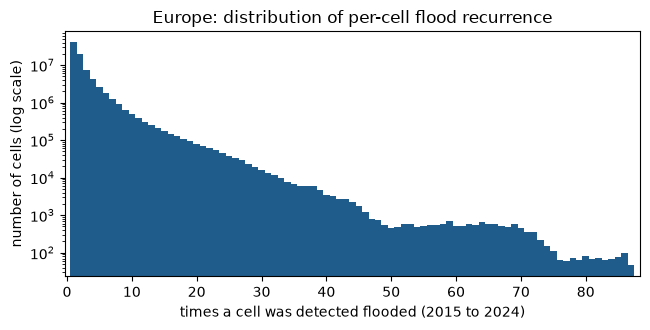

In [5]:
hist = pd.read_csv(S.RESULTS / "recurrence_hist.csv")
fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.bar(hist["recurrence"], hist["cells"], width=1.0, color="#1f5c8b")
ax.set_yscale("log")
ax.set_xlabel("times a cell was detected flooded (2015 to 2024)")
ax.set_ylabel("number of cells (log scale)")
ax.set_title("Europe: distribution of per-cell flood recurrence")
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

In [6]:
# Key figures. The continental aggregates are the paper's frozen result (a full-continent
# recurrence raster does not fit in memory); the max is also reproduced live above at Aveiro.
stats = json.loads((S.RESULTS / "fig_a_stats.json").read_text())
from IPython.display import Markdown  # noqa: E402

Markdown(
    f"### Key figures\n"
    f"| | |\n|---|---|\n"
    f"| **Archived events (2015 to 2024)** | **{len(cat):,}** |\n"
    f"| **Area flooded at least once** | **{stats['area_flooded_at_least_once_km2']:,.0f} km²** |\n"
    f"| **Cells flooded more than once** | **{stats['cells_recurrence_ge2_fraction']:.1%}** |\n"
    f"| **Most-flooded cell (Vouga / Aveiro, PT)** | **{max(int(k) for k in stats['cells_by_recurrence'])} times** |\n"
)

### Key figures
| | |
|---|---|
| **Archived events (2015 to 2024)** | **2,942** |
| **Area flooded at least once** | **376,857 km²** |
| **Cells flooded more than once** | **51.3%** |
| **Most-flooded cell (Vouga / Aveiro, PT)** | **87 times** |


## The published figure

The paper's Fig. 5: the full-resolution per-cell recurrence surface for the whole continent
(streamed from the index and max-pooled for display), shown here for comparison.

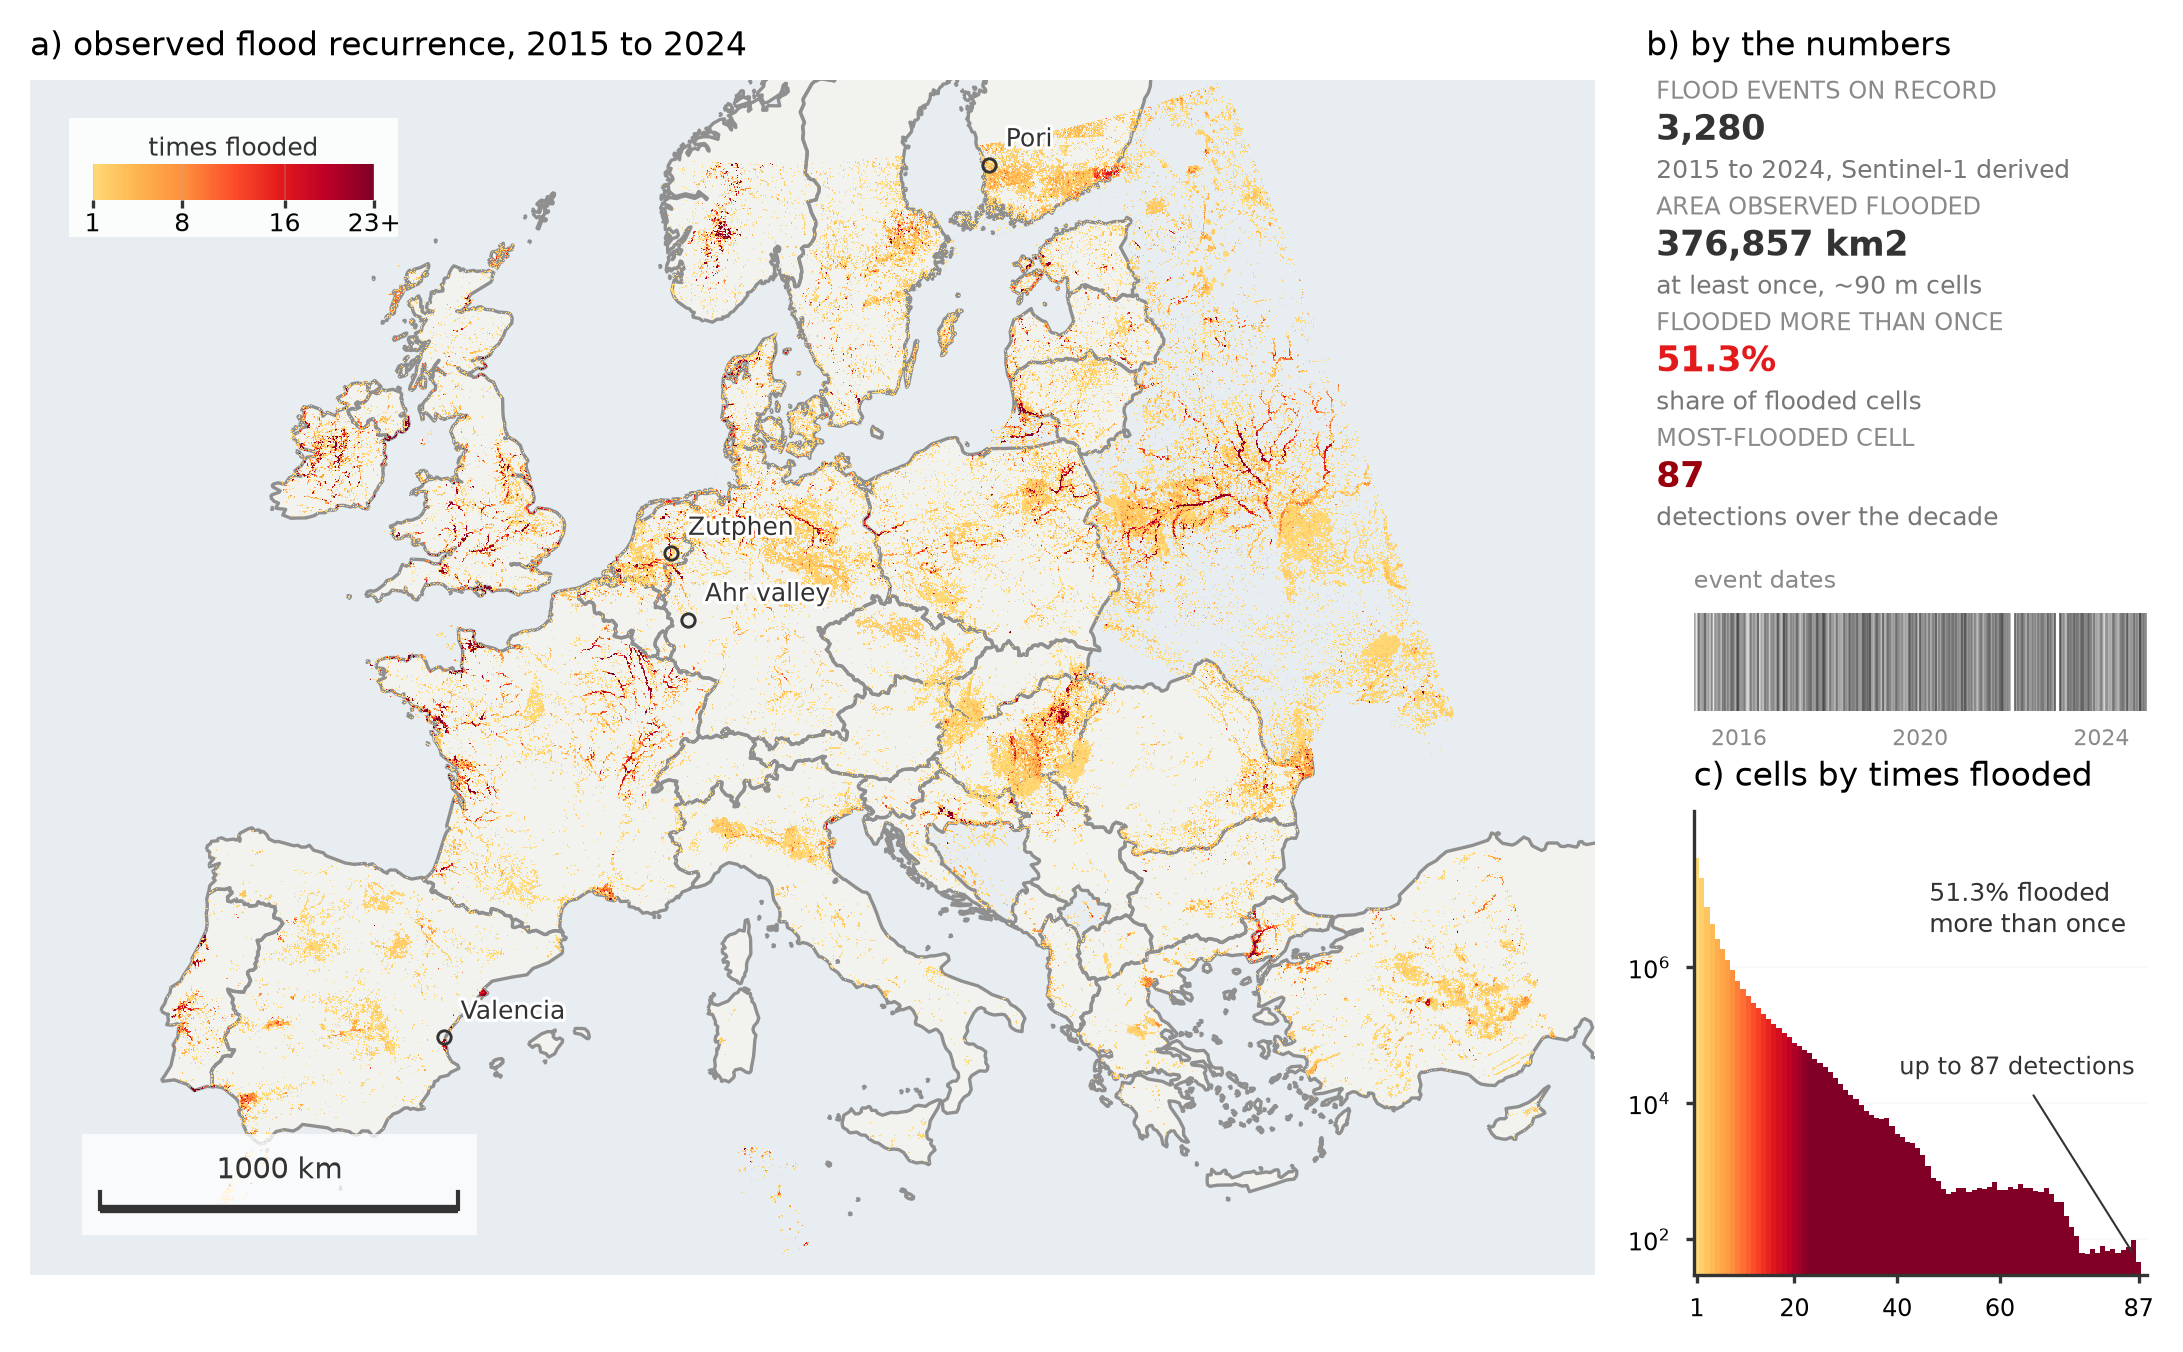

In [7]:
S.published_figure("recurrence")

## Interpretation

One discovery query, read from the index alone, yields a decade-long recurrence surface for a
continent, which is the point: no event rasters are downloaded, aligned, or stacked. Two
cautions on reading it:

1. **Recurrence is a detection count, not a return period.** It counts how many archived events
   were detected at a cell, not statistically independent floods, and cannot be converted into an
   annual exceedance probability or a return period.
2. **An event is an archive cluster.** Each archived event is a spatio-temporal cluster of
   satellite observations, not necessarily one hydrological flood, and detection reflects
   Sentinel-1 acquisition timing and detectability as much as flood occurrence. The continental
   map is max-pooled for display only.

## References and reuse

This notebook reproduces the continental recurrence application (main text Section 7.1, Fig. 5)
of:

> J. Hackl (2026). *EuroFlood: a Python library and queryable index for the CEMS
> satellite-derived flood-depth archive of Europe.*